In [166]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [167]:
# ==========================================
# LECTURA DE ARCHIVO Y EXPLORACIÓN DE DATOS
# ==========================================

# Leer dataset proveniente del csv
vg_data = pd.read_csv("../dato.csv")

print('_'*40)

#Leer ultimos datos del dataset
vg_data.tail()

print('_'*40)

#Leer info general del dataset
vg_data.info()

print('_'*40)

#Leer cuantos datos hay en cada columna
vg_data.count()

print('_'*40)

________________________________________
________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7112 entries, 0 to 7111
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Platform            7112 non-null   object
 1   Genre               7112 non-null   object
 2   Publisher           7112 non-null   object
 3   NA_Sales            7112 non-null   object
 4   EU_Sales            7112 non-null   object
 5   JP_Sales            7112 non-null   object
 6   Other_Sales         7112 non-null   object
 7   Global_Sales        7112 non-null   object
 8   Rating              7112 non-null   object
 9   Critic_Score_Class  7112 non-null   object
dtypes: object(10)
memory usage: 555.8+ KB
________________________________________
________________________________________


In [168]:
# ==========================================
# REFACTORIZACIÓN DE DATOS
# ==========================================

# Eliminar filas con valores nulos o vacios para evitar errores de entrenamiento
vg_data = vg_data.dropna()

# Reemplazar coma por punto
vg_data["NA_Sales"] = vg_data["NA_Sales"].astype(str).str.replace(",", ".")
vg_data["EU_Sales"] = vg_data["EU_Sales"].astype(str).str.replace(",", ".")
vg_data["JP_Sales"] = vg_data["JP_Sales"].astype(str).str.replace(",", ".")
vg_data["Other_Sales"] = vg_data["Other_Sales"].astype(str).str.replace(",", ".")
vg_data["Global_Sales"] = vg_data["Global_Sales"].astype(str).str.replace(",", ".")

# Convertir a float
vg_data["NA_Sales"] = vg_data["NA_Sales"].astype(float)
vg_data["EU_Sales"] = vg_data["EU_Sales"].astype(float)
vg_data["JP_Sales"] = vg_data["JP_Sales"].astype(float)
vg_data["Other_Sales"] = vg_data["Other_Sales"].astype(float)
vg_data["Global_Sales"] = vg_data["Global_Sales"].astype(float)

print(vg_data.head(10))

  Platform     Genre               Publisher  NA_Sales  EU_Sales  JP_Sales  \
0      Wii    Sports                Nintendo     41.36     28.96      3.77   
1      Wii    Racing                Nintendo     15.68     12.80      3.79   
2      Wii    Sports                Nintendo     15.61     10.95      3.28   
3       DS  Platform                Nintendo     11.28      9.15      6.50   
4      Wii      Misc                Nintendo     13.96      9.18      2.93   
5      Wii  Platform                Nintendo     14.48      6.95      4.70   
6       DS    Racing                Nintendo      9.71      7.48      4.13   
7      Wii    Sports                Nintendo      8.92      8.03      3.60   
8     X360      Misc  Microsoft Game Studios     15.02      4.91      0.24   
9      Wii    Sports                Nintendo      9.01      8.49      2.53   

   Other_Sales  Global_Sales Rating Critic_Score_Class  
0         8.45         82.54      E              Bueno  
1         3.29         35.5

In [169]:
# ==========================================
# VARIABLES OBJETIVO Y DE ENTRENAMIENTO 
# ==========================================

# Convertir Critic_Score_Class a valores numéricos
label_encoder = LabelEncoder()

vg_data["Critic_Score_Class"] = label_encoder.fit_transform(
    vg_data["Critic_Score_Class"]
)

# Definir parametros de entrenamiento y prueba
X = vg_data[["Platform", "Genre", "Publisher", "Rating"]]

# Definir variables objetivo
y = vg_data[
    [
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales",
        "Critic_Score_Class"
    ]
]

In [170]:
# ==========================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ==========================================

# Definir variables categóricas para codificación
categorical_features = [
    "Platform",
    "Genre",
    "Publisher",
    "Rating"
]

#Crear transformador para codificar variables categóricas
ct = ColumnTransformer(
    transformers=[
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# Aplicar transformador a los datos de entrenamiento
X = ct.fit_transform(X)

In [ ]:
# ==========================================
# SEPARACIÓN DE DATOS DE ENTRENAMIENTO Y PRUEBA
# ==========================================

# Separar dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# ==========================================
# ESCALAMIENTO DE VARIABLES OBJETIVO
# ==========================================

# Escalamiento de variables objetivo
scaler = StandardScaler()

# Escalar SOLO entrenamiento
y_train_scaled= scaler.fit_transform(y_train)

# Aplicar el mismo escalamiento a prueba
y_test_scaled= scaler.transform(y_test)

In [ ]:
# ==========================================
# CANTIDAD DE DATOS POR CONJUNTO
# ==========================================

# Tabla con cantidad de datos
tabla_procesamiento = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Cantidad de datos": [
        X_train.shape[0],
        X_test.shape[0]
    ]
})

print(tabla_procesamiento)

        Conjunto  Cantidad de datos
0  Entrenamiento               5689
1         Prueba               1423


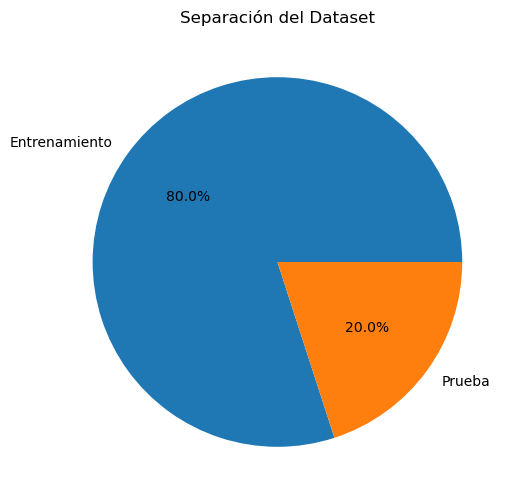

In [ ]:
# ==========================================
# GRAFICA DE SEPARACIÓN DEL DATASET
# ==========================================

#Gráfica de pastel para mostrar la separación del dataset
fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    [X_train.shape[0], X_test.shape[0]],
    labels=["Entrenamiento", "Prueba"],
    autopct='%1.1f%%'
)

ax.set_title("Separación del Dataset")

plt.show()


===== DATOS ANTES DEL ESCALAMIENTO =====



,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score_Class
0,41.36,28.96,3.77,8.45,82.54,1.0
1,15.68,12.80,3.79,3.29,35.57,2.0
2,15.61,10.95,3.28,2.95,32.78,2.0
3,11.28,9.15,6.50,2.88,29.81,2.0
4,13.96,9.18,2.93,2.84,28.92,3.0
5,14.48,6.95,4.70,2.25,28.38,2.0
6,9.71,7.48,4.13,1.90,23.22,2.0
7,8.92,8.03,3.60,2.15,22.70,2.0
8,15.02,4.91,0.24,1.69,21.86,0.0
9,9.01,8.49,2.53,1.77,21.79,2.0



===== DATOS DESPUÉS DEL ESCALAMIENTO =====



,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score_Class
0,-0.394213,0.351967,0.630424,-0.183122,-0.006085,0.517348
1,-0.139773,-0.198002,-0.212653,-0.254406,-0.208481,-0.417890
2,1.193495,0.521188,-0.145207,0.529718,0.818311,0.517348
3,-0.058352,-0.198002,-0.212653,-0.254406,-0.164052,0.517348
4,-0.251727,-0.310816,0.326916,-0.218764,-0.208481,-0.417890
5,-0.333147,-0.254409,-0.212653,-0.218764,-0.317084,1.452586
6,-0.272082,-0.268511,-0.212653,-0.290048,-0.292401,-0.417890
7,-0.373858,-0.310816,-0.212653,-0.290048,-0.361512,-0.417890
8,-0.363680,-0.296715,2.282854,-0.254406,0.018598,-0.417890
9,-0.394213,-0.296715,-0.212653,-0.290048,-0.366449,-0.417890


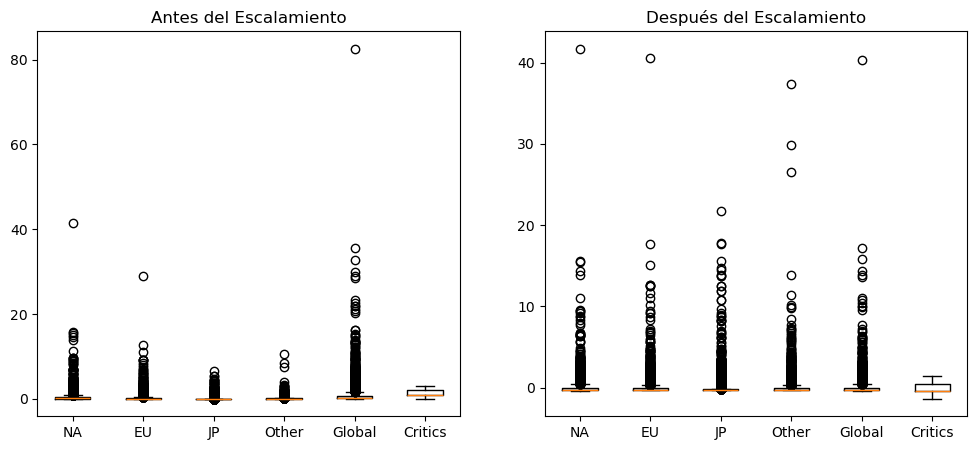

In [175]:
# ==========================================
# DATAFRAME CON DATOS ESCALADOS
# ==========================================

y_train_scaled_df = pd.DataFrame(
    y_train_scaled,
    columns=[
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales",
        "Critic_Score_Class"
    ]
)

# ==========================================
# DATAFRAME ANTES DEL ESCALAMIENTO
# ==========================================

before_scaling = vg_data[
    [
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales",
        "Critic_Score_Class"
    ]
].astype(float)

# ==========================================
# DATAFRAME DESPUÉS DEL ESCALAMIENTO
# ==========================================

after_scaling = y_train_scaled_df[
    [
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales",
        "Critic_Score_Class"
    ]
].astype(float)

# ==========================================
# MOSTRAR TABLAS
# ==========================================

print("\n===== DATOS ANTES DEL ESCALAMIENTO =====\n")
display(before_scaling.head(10))

print("\n===== DATOS DESPUÉS DEL ESCALAMIENTO =====\n")
display(after_scaling.head(10))

# ==========================================
# GRAFICAR BOXPLOTS
# ==========================================

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Antes del escalamiento
ax[0].boxplot(
    before_scaling.values
)

ax[0].set_title(
    "Antes del Escalamiento"
)

ax[0].set_xticklabels([
    "NA",
    "EU",
    "JP",
    "Other",
    "Global",
    "Critics"
])

# Después del escalamiento
ax[1].boxplot(
    after_scaling.values
)

ax[1].set_title(
    "Después del Escalamiento"
)

ax[1].set_xticklabels([
    "NA",
    "EU",
    "JP",
    "Other",
    "Global",
    "Critics"
])

plt.show()


CREACION DEL MODELO EN BASE A TRAIN

In [ ]:
# ==========================================
# CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ==========================================

#Creacion del modelo
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score= True
)

# Entrenar modelo
model.fit(X_train, y_train_scaled)

RandomForestRegressor(oob_score=True, random_state=42)

In [ ]:
# ==========================================
# PREDICCIÓN Y EVALUACIÓN DEL MODELO
# ==========================================

print("Out-of-Bag Score:", model.oob_score_)

y_pred_scaled = model.predict(X_train)

# Regresar valores a escala original
y_pred = scaler.inverse_transform(y_pred_scaled)


Out-of-Bag Score: 0.07145547039248891


In [ ]:
# ==========================================
# VALORES DE PREDICCIÓN EN TRAIN
# ==========================================

# Recuperar filas originales del CSV
test_original = vg_data.loc[y_train.index].copy()

# Valores reales convertidos a texto
critic_real_text = label_encoder.inverse_transform(
    y_train["Critic_Score_Class"].astype(int)
)

# Valores predichos convertidos a texto
critic_pred_text = label_encoder.inverse_transform(
    np.round(y_pred[:, 5]).astype(int)
)

# ==========================================
# TABLA DE RESULTADOS
# ==========================================

resultados = pd.DataFrame({

    # Datos originales del CSV
    "Platform": test_original["Platform"].values,
    "Genre": test_original["Genre"].values,
    "Publisher": test_original["Publisher"].values,
    "Rating": test_original["Rating"].values,

    "Real NA": y_train["NA_Sales"].values,
    "Pred NA": y_pred[:, 0],

    "Real EU": y_train["EU_Sales"].values,
    "Pred EU": y_pred[:, 1],

    "Real JP": y_train["JP_Sales"].values,
    "Pred JP": y_pred[:, 2],

    "Real Other": y_train["Other_Sales"].values,
    "Pred Other": y_pred[:, 3],

    "Real Global": y_train["Global_Sales"].values,
    "Pred Global": y_pred[:, 4],

    # Critic Score como texto
    "Real Critic": critic_real_text,
    "Pred Critic": critic_pred_text

})

# Redondear columnas numéricas
columnas_numericas = [
    "Real NA",
    "Pred NA",
    "Real EU",
    "Pred EU",
    "Real JP",
    "Pred JP",
    "Real Other",
    "Pred Other",
    "Real Global",
    "Pred Global"
]

resultados[columnas_numericas] = (
    resultados[columnas_numericas]
    .round(2)
)

styled_results = (
    resultados.head(20).style
    .set_properties(**{
        "text-align": "center",
        "font-size": "10pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])
    .background_gradient(
        cmap="Blues",
        subset=columnas_numericas
    )
)

styled_results


,Platform,Genre,Publisher,Rating,Real NA,Pred NA,Real EU,Pred EU,Real JP,Pred JP,Real Other,Pred Other,Real Global,Pred Global,Real Critic,Pred Critic
0,3DS,Puzzle,Nintendo,E10+,0.000000,0.150000,0.480000,0.510000,0.250000,0.300000,0.030000,0.070000,0.750000,1.030000,Excelente,Excelente
1,GBA,Action,Atari,T,0.250000,0.270000,0.090000,0.100000,0.000000,0.000000,0.010000,0.010000,0.340000,0.370000,Bueno,Bueno
2,X360,Shooter,Ubisoft,M,1.560000,0.680000,0.600000,0.390000,0.020000,0.010000,0.230000,0.110000,2.420000,1.190000,Excelente,Excelente
3,GC,Sports,Electronic Arts,E,0.330000,0.220000,0.090000,0.060000,0.000000,0.000000,0.010000,0.010000,0.430000,0.290000,Excelente,Excelente
4,PSP,Role-Playing,Square Enix,T,0.140000,0.430000,0.010000,0.170000,0.160000,0.300000,0.020000,0.130000,0.340000,1.030000,Bueno,Bueno
5,PS2,Platform,Ubisoft,E,0.060000,0.120000,0.050000,0.090000,0.000000,0.000000,0.020000,0.030000,0.120000,0.240000,Malo,Excelente
6,GBA,Shooter,Electronic Arts,T,0.120000,0.120000,0.040000,0.040000,0.000000,0.000000,0.000000,0.000000,0.170000,0.160000,Bueno,Bueno
7,X,Adventure,Ubisoft,T,0.020000,0.090000,0.010000,0.040000,0.000000,0.000000,0.000000,0.000000,0.030000,0.130000,Bueno,Bueno
8,PS2,Action,Sega,M,0.030000,0.080000,0.020000,0.060000,0.740000,0.120000,0.010000,0.020000,0.800000,0.280000,Bueno,Bueno
9,PC,Adventure,Ubisoft,E,0.000000,0.000000,0.020000,0.020000,0.000000,0.000000,0.000000,0.000000,0.020000,0.020000,Bueno,Bueno


In [179]:
# ==========================================
# VARIABLES DE REGRESIÓN
# ==========================================

variables_regresion = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

# Predicciones
predicciones_regresion = y_pred[:, 0:5]

# ==========================================
# MÉTRICAS POR CADA VARIABLE
# ==========================================

for i, variable in enumerate(variables_regresion):

    real = y_train[variable]

    pred = predicciones_regresion[:, i]

    # ----------------------------
    # MÉTRICAS
    # ----------------------------

    mae = mean_absolute_error(
        real,
        pred
    )

    mse = mean_squared_error(
        real,
        pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        real,
        pred
    )

    # ----------------------------
    # TABLA
    # ----------------------------

    tabla_metricas = pd.DataFrame({

        "Métrica": [
            "MAE",
            "MSE",
            "RMSE",
            "R² Score"
        ],

        "Valor": [
            mae,
            mse,
            rmse,
            r2
        ]
    })

    # Redondear
    tabla_metricas["Valor"] = (
        tabla_metricas["Valor"]
        .astype(float)
        .round(4)
    )

    print(f"\n===== MÉTRICAS DE {variable} =====\n")

    styled_table = (

        tabla_metricas.style

        .set_properties(**{
            "text-align": "center",
            "font-size": "11pt"
        })

        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1F4E78"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center")
                ]
            }
        ])

        .background_gradient(
            cmap="Blues",
            subset=["Valor"]
        )

    )

    display(styled_table)

# ==========================================
# MÉTRICAS DE CLASIFICACIÓN
# ==========================================

critic_real = y_train[
    "Critic_Score_Class"
].values

critic_pred = np.round(
    y_pred[:, 5]
).astype(int)

# Limitar rango
critic_pred = np.clip(
    critic_pred,
    critic_real.min(),
    critic_real.max()
)

# Accuracy
accuracy = accuracy_score(
    critic_real,
    critic_pred
)

# Precision
precision = precision_score(
    critic_real,
    critic_pred,
    average="weighted"
)

# Recall
recall = recall_score(
    critic_real,
    critic_pred,
    average="weighted"
)

# F1
f1 = f1_score(
    critic_real,
    critic_pred,
    average="weighted"
)

# ==========================================
# TABLA CLASIFICACIÓN
# ==========================================

tabla_clasificacion = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Valor": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

tabla_clasificacion["Valor"] = (
    tabla_clasificacion["Valor"]
    .astype(float)
    .round(4)
)

print("\n===== MÉTRICAS DE Critic_Score_Class =====\n")

styled_classification = (

    tabla_clasificacion.style

    .set_properties(**{
        "text-align": "center",
        "font-size": "11pt"
    })

    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])

    .background_gradient(
        cmap="Blues",
        subset=["Valor"]
    )

)

display(styled_classification)


===== MÉTRICAS DE NA_Sales =====



,Métrica,Valor
0,MAE,0.228500
1,MSE,0.482500
2,RMSE,0.694700
3,R² Score,0.500200



===== MÉTRICAS DE EU_Sales =====



,Métrica,Valor
0,MAE,0.156200
1,MSE,0.257800
2,RMSE,0.507700
3,R² Score,0.487400



===== MÉTRICAS DE JP_Sales =====



...

,Métrica,Valor
0,MAE,0.054600
1,MSE,0.049100
2,RMSE,0.221600
3,R² Score,0.375900



===== MÉTRICAS DE Global_Sales =====



,Métrica,Valor
0,MAE,0.450900
1,MSE,2.034500
2,RMSE,1.426400
3,R² Score,0.504200



===== MÉTRICAS DE Critic_Score_Class =====



,Métrica,Valor
0,Accuracy,0.548600
1,Precision,0.694800
2,Recall,0.548600
3,F1 Score,0.533500



===== MATRIZ DE CONFUSIÓN TRAIN =====



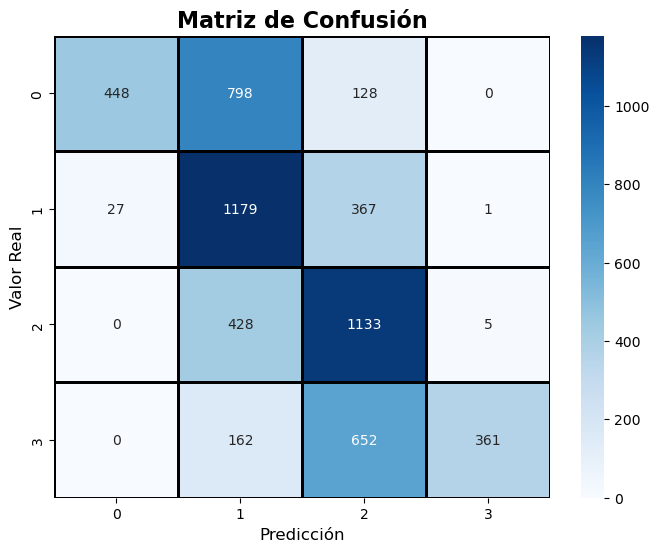

In [180]:
# ==========================================
# MATRIZ DE CONFUSIÓN
# ==========================================

from sklearn.metrics import confusion_matrix

critic_real = y_train["Critic_Score_Class"].values

critic_pred = np.round(y_pred[:, 5]).astype(int)

# Evitar valores fuera de rango
critic_pred = np.clip(
    critic_pred,
    critic_real.min(),
    critic_real.max()
)

# Crear matriz
matrix = confusion_matrix(
    critic_real,
    critic_pred
)

print("\n===== MATRIZ DE CONFUSIÓN TRAIN =====\n")

# ==========================================
# GRAFICAR MATRIZ
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=True
)

plt.title(
    "Matriz de Confusión",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicción",
    fontsize=12
)

plt.ylabel(
    "Valor Real",
    fontsize=12
)

plt.show()


CREACION DEL MODELO EN BASE A TEST

In [ ]:
# ==========================================
# PREDICCION EN TEST
# ==========================================

y_pred_test_scaled = model.predict(X_test)

# Regresar a escala original
y_pred_test = scaler.inverse_transform(
    y_pred_test_scaled
)

In [182]:
# Recuperar filas originales del CSV
test_original = vg_data.loc[y_test.index].copy()

# Valores reales convertidos a texto
critic_real_text = label_encoder.inverse_transform(
    y_test["Critic_Score_Class"].astype(int)
)

# Valores predichos convertidos a texto
critic_pred_text = label_encoder.inverse_transform(
    np.round(y_pred_test[:, 5]).astype(int)
)

# ==========================================
# TABLA DE RESULTADOS
# ==========================================

resultados = pd.DataFrame({

    # Datos originales del CSV
    "Platform": test_original["Platform"].values,
    "Genre": test_original["Genre"].values,
    "Publisher": test_original["Publisher"].values,
    "Rating": test_original["Rating"].values,

    "Real NA": y_test["NA_Sales"].values,
    "Pred NA": y_pred_test[:, 0],

    "Real EU": y_test["EU_Sales"].values,
    "Pred EU": y_pred_test[:, 1],

    "Real JP": y_test["JP_Sales"].values,
    "Pred JP": y_pred_test[:, 2],

    "Real Other": y_test["Other_Sales"].values,
    "Pred Other": y_pred_test[:, 3],

    "Real Global": y_test["Global_Sales"].values,
    "Pred Global": y_pred_test[:, 4],

    # Critic Score como texto
    "Real Critic": critic_real_text,
    "Pred Critic": critic_pred_text

})

# Redondear columnas numéricas
columnas_numericas = [
    "Real NA",
    "Pred NA",
    "Real EU",
    "Pred EU",
    "Real JP",
    "Pred JP",
    "Real Other",
    "Pred Other",
    "Real Global",
    "Pred Global"
]

resultados[columnas_numericas] = (
    resultados[columnas_numericas]
    .round(2)
)

# ==========================================
# TABLA BONITA
# ==========================================

styled_results = (
    resultados.head(20).style
    .set_properties(**{
        "text-align": "center",
        "font-size": "10pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])
    .background_gradient(
        cmap="Blues",
        subset=columnas_numericas
    )
)

styled_results


,Platform,Genre,Publisher,Rating,Real NA,Pred NA,Real EU,Pred EU,Real JP,Pred JP,Real Other,Pred Other,Real Global,Pred Global,Real Critic,Pred Critic
0,Wii,Action,D3Publisher,E10+,0.250000,0.220000,0.140000,0.170000,0.000000,0.000000,0.040000,0.040000,0.440000,0.440000,Aceptable,Excelente
1,X360,Role-Playing,Square Enix,T,0.260000,0.420000,0.000000,0.230000,0.020000,0.070000,0.020000,0.070000,0.300000,0.790000,Aceptable,Bueno
2,PS2,Adventure,Indie Games,T,0.020000,0.060000,0.010000,0.050000,0.000000,0.010000,0.000000,0.020000,0.040000,0.140000,Aceptable,Excelente
3,PS2,Action,Vivendi Games,E,0.180000,0.320000,0.140000,0.240000,0.000000,0.010000,0.050000,0.080000,0.360000,0.650000,Malo,Excelente
4,DS,Action,Electronic Arts,E,0.070000,0.230000,0.000000,0.360000,0.000000,0.000000,0.010000,0.080000,0.070000,0.670000,Malo,Malo
5,X360,Racing,Codemasters,E,0.030000,0.150000,0.050000,0.340000,0.000000,0.000000,0.010000,0.060000,0.090000,0.560000,Bueno,Bueno
6,PSP,Role-Playing,Konami Digital Entertainment,E10+,0.040000,0.070000,0.000000,0.030000,0.000000,0.100000,0.000000,0.010000,0.050000,0.220000,Aceptable,Excelente
7,GC,Role-Playing,Sega,T,0.060000,0.040000,0.020000,0.020000,0.000000,0.050000,0.000000,0.010000,0.080000,0.110000,Bueno,Excelente
8,X360,Action,Ubisoft,M,3.120000,1.680000,1.550000,0.780000,0.080000,0.020000,0.520000,0.240000,5.270000,2.720000,Excelente,Excelente
9,GC,Platform,Electronic Arts,E,0.150000,0.220000,0.040000,0.060000,0.000000,0.000000,0.010000,0.010000,0.200000,0.300000,Aceptable,Bueno


In [183]:
# ==========================================
# VARIABLES DE REGRESIÓN
# ==========================================

variables_regresion = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

# Predicciones
predicciones_regresion = y_pred_test[:, 0:5]

# ==========================================
# MÉTRICAS POR CADA VARIABLE
# ==========================================

for i, variable in enumerate(variables_regresion):

    real = y_test[variable]

    pred = predicciones_regresion[:, i]

    # ----------------------------
    # MÉTRICAS
    # ----------------------------

    mae = mean_absolute_error(
        real,
        pred
    )

    mse = mean_squared_error(
        real,
        pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        real,
        pred
    )

    # ----------------------------
    # TABLA
    # ----------------------------

    tabla_metricas = pd.DataFrame({

        "Métrica": [
            "MAE",
            "MSE",
            "RMSE",
            "R² Score"
        ],

        "Valor": [
            mae,
            mse,
            rmse,
            r2
        ]
    })

    # Redondear
    tabla_metricas["Valor"] = (
        tabla_metricas["Valor"]
        .astype(float)
        .round(4)
    )

    print(f"\n===== MÉTRICAS DE {variable} =====\n")

    styled_table = (

        tabla_metricas.style

        .set_properties(**{
            "text-align": "center",
            "font-size": "11pt"
        })

        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1F4E78"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center")
                ]
            }
        ])

        .background_gradient(
            cmap="Blues",
            subset=["Valor"]
        )

    )

    display(styled_table)

# ==========================================
# MÉTRICAS DE CLASIFICACIÓN
# ==========================================

critic_real = y_test[
    "Critic_Score_Class"
].values

critic_pred = np.round(
    y_pred_test[:, 5]
).astype(int)

# Limitar rango
critic_pred = np.clip(
    critic_pred,
    critic_real.min(),
    critic_real.max()
)

# Accuracy
accuracy = accuracy_score(
    critic_real,
    critic_pred
)

# Precision
precision = precision_score(
    critic_real,
    critic_pred,
    average="weighted"
)

# Recall
recall = recall_score(
    critic_real,
    critic_pred,
    average="weighted"
)

# F1
f1 = f1_score(
    critic_real,
    critic_pred,
    average="weighted"
)

# ==========================================
# TABLA CLASIFICACIÓN
# ==========================================

tabla_clasificacion = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Valor": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

tabla_clasificacion["Valor"] = (
    tabla_clasificacion["Valor"]
    .astype(float)
    .round(4)
)

print("\n===== MÉTRICAS DE Critic_Score_Class =====\n")

styled_classification = (

    tabla_clasificacion.style

    .set_properties(**{
        "text-align": "center",
        "font-size": "11pt"
    })

    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])

    .background_gradient(
        cmap="Blues",
        subset=["Valor"]
    )

)

display(styled_classification)


===== MÉTRICAS DE NA_Sales =====



,Métrica,Valor
0,MAE,0.324600
1,MSE,0.639300
2,RMSE,0.799500
3,R² Score,0.071200



===== MÉTRICAS DE EU_Sales =====



,Métrica,Valor
0,MAE,0.237200
1,MSE,0.324700
2,RMSE,0.569800
3,R² Score,-0.080900



===== MÉTRICAS DE JP_Sales =====



...

,Métrica,Valor
0,MAE,0.076400
1,MSE,0.040800
2,RMSE,0.201900
3,R² Score,-0.058300



===== MÉTRICAS DE Global_Sales =====



,Métrica,Valor
0,MAE,0.650500
1,MSE,2.381800
2,RMSE,1.543300
3,R² Score,-0.018900



===== MÉTRICAS DE Critic_Score_Class =====



,Métrica,Valor
0,Accuracy,0.344300
1,Precision,0.354000
2,Recall,0.344300
3,F1 Score,0.296500



===== MATRIZ DE CONFUSIÓN TEST =====



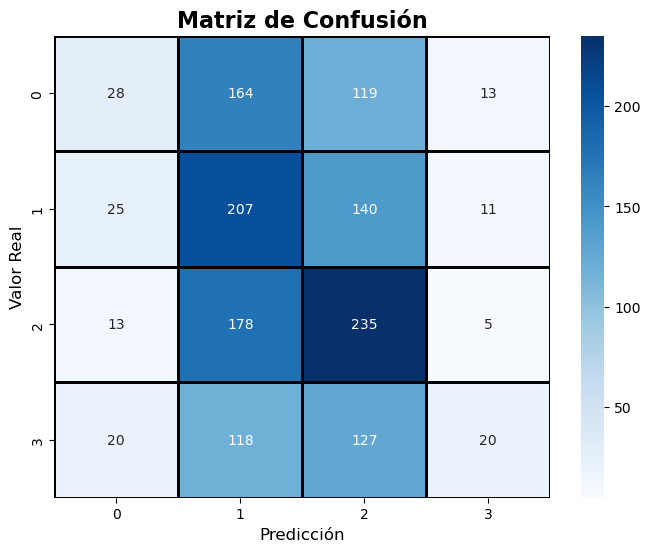

In [184]:
# ==========================================
# MATRIZ DE CONFUSIÓN
# ==========================================

from sklearn.metrics import confusion_matrix

critic_real = y_test["Critic_Score_Class"].values

critic_pred = np.round(y_pred_test[:, 5]).astype(int)

# Evitar valores fuera de rango
critic_pred = np.clip(
    critic_pred,
    critic_real.min(),
    critic_real.max()
)

# Crear matriz
matrix = confusion_matrix(
    critic_real,
    critic_pred
)

print("\n===== MATRIZ DE CONFUSIÓN TEST =====\n")

# ==========================================
# GRAFICAR MATRIZ
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=True
)

plt.title(
    "Matriz de Confusión",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicción",
    fontsize=12
)

plt.ylabel(
    "Valor Real",
    fontsize=12
)

plt.show()